In [16]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('').resolve()))
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import utils as U

In [17]:
DATA = pathlib.Path('..') / 'data'
df_raw = pd.read_excel(DATA / 'quality_analisys.xlsx')

word_cols = ['word_1', 'word_2', 'word_3', 'word_4', 'word_5']

# Flatten → unique words (lowercase)
words_flat = (
    df_raw[word_cols]
    .stack()
    .str.lower()
    .str.strip()
    .dropna()
)
unique_words = sorted(words_flat.unique())
print(f'Total tokens: {len(words_flat)}  |  Unique: {len(unique_words)}')
print(unique_words[0:])


Total tokens: 278  |  Unique: 151
['-', 'abundant', 'accessibility', 'accordance', 'accuracy', 'afirmative', 'amount', 'analysis', 'anotation', 'anova', 'approximation', 'autorization', 'availability', 'avaliation', 'balance', 'balancing', 'bias', 'business', 'cheap', 'clarity', 'cleaning', 'coherence', 'cohesion', 'collect', 'complete data', 'completeness', 'compliance', 'comprehensibility', 'comprehensiblity', 'consistency', 'correctness', 'credibility', 'current', 'data analysis', 'data bank', 'dataleakage', 'dataset', 'dependency', 'desbalancing', 'descriptive', 'determination', 'distinction', 'distribution', 'diversity', 'duplication', 'eda', 'effectiveness', 'efficiency', 'encoder', 'enough data', 'especialists', 'essential', 'expensive', 'explainability', 'filters', 'format', 'formatted', 'foundation', 'granularity', 'identifiable', 'iid', 'important', 'incompleteness', 'inconsistency', 'incorrect', 'indefined', 'indispensable', 'information', 'integration', 'integrity', 'interd

In [18]:
groups = {
    "quality": [
        "quality", "qualified", "reliability", "reliable", "reliablity",
        "credibility", "correctness", "accuracy", "precision"
    ],
    "completeness": [
        "completeness", "complete data", "incompleteness", "missing",
        "null", "null data", "nullity", "enough data", "abundant"
    ],
    "consistency": [
        "consistency", "inconsistency", "coherence", "cohesion",
        "stability", "symmetry", "balance"
    ],
    "volume": [
        "volume", "quantity", "amount", "scale"
    ],
    "representativeness": [
        "representativeness", "diversity", "distribution", "iid",
        "desbalancing", "balancing", "bias"
    ],
    "noise": [
        "noise", "outlier", "outliers", "outliners", "signal"
    ],
    "freshness": [
        "current", "old", "update", "time", "streaming", "real"
    ],
    "provenance": [
        "provenance", "origin", "source", "traceability", "rastreabilidade",
        "foundation"
    ],
    "clarity": [
        "clarity", "comprehensibility", "comprehensiblity", "explainability",
        "transparency", "anotation", "read_me", "descriptive"
    ],
    "compliance": [
        "compliance", "accordance", "autorization", "security",
        "identifiable", "afirmative"
    ],
    "accessibility": [
        "accessibility", "availability", "use", "reuse"
    ],
    "integrity": [
        "integrity", "keys", "duplication", "dependency",
        "multicollinearity", "relation"
    ],
    "structure": [
        "structure", "organization", "organisation", "format", "formatted",
        "standard", "standardization", "standartise", "granularity",
        "type", "term"
    ],
    "processing": [
        "processing", "cleaning", "sanitize", "normalization", "transformed",
        "encoder", "filters", "split", "tractate"
    ],
    "analysis": [
        "analysis", "data analysis", "eda", "anova", "regression",
        "approximation", "variance", "measurement", "determination",
        "distinction"
    ],
    "visualization": [
        "visualisation", "plotting"
    ],
    "performance": [
        "performance", "performace", "efficiency", "effectiveness",
        "otimization", "scalability"
    ],
    "cost": [
        "cheap", "expensive", "investiment", "time-consuming"
    ],
    "pipeline": [
        "pipeline", "collect", "integration", "dataset", "data bank",
        "training", "test", "result"
    ],
    "validation": [
        "validation", "validate", "validade", "verify", "avaliation",
        "dataleakage"
    ],
    "relevance": [
        "relevance", "important", "essential", "necessary", "indispensable",
        "neglected", "value", "information"
    ],
    "expertise": [
        "especialists", "interdisciplinarity", "subjectivity", "business",
        "technique", "requisit"
    ],
    "transferability": [
        "transferability"
    ],
    "invalid": [
        "-", "incorrect", "indefined"
    ],
}

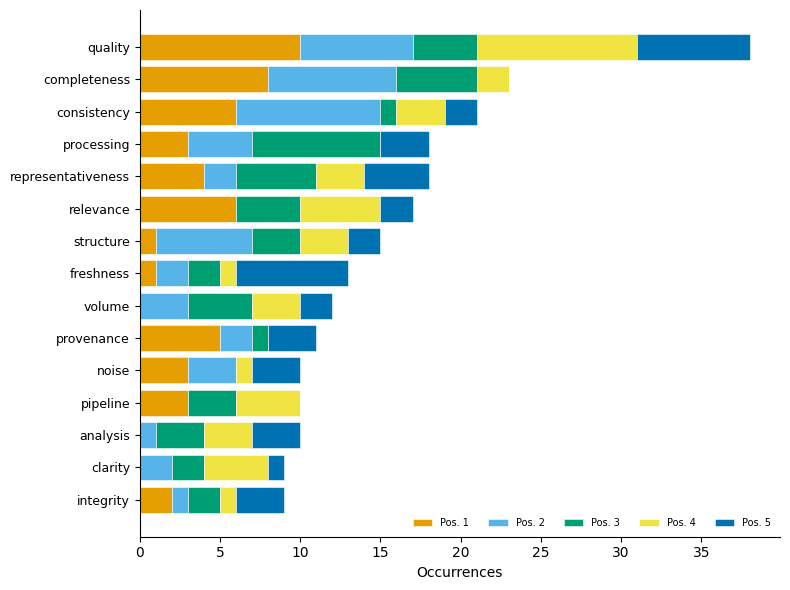

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --- invert grupos dict: word -> label ---
word_to_label = {w: label for label, words in groups.items() for w in words}

# --- rebuild (word, position) from raw data ---
word_pos = (
    df_raw[word_cols]
    .stack()
    .str.lower()
    .str.strip()
    .dropna()
    .reset_index()
)
word_pos.columns = ['resp_idx', 'word_col', 'word']
word_pos['position'] = word_pos['word_col'].str.extract(r'(\d+)').astype(int)

# --- map word to semantic group label ---
word_pos['label'] = word_pos['word'].map(word_to_label).fillna('unknown')

# --- aggregate: count per (label, position) ---
agg = (
    word_pos.groupby(['label', 'position'])
    .size()
    .unstack(fill_value=0)
)
pos_cols = sorted(agg.columns)

agg = agg.loc[agg.sum(axis=1).sort_values(ascending=False).head(15).index]

# opcional: reordenar para manter o maior no topo do gráfico
agg = agg.iloc[::-1]

# --- plot ---
try:
    colors = U.PALETTE_WONG[1 : len(pos_cols) + 1]
except Exception:
    colors = plt.cm.tab10.colors[: len(pos_cols)]

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(agg))
bottom = np.zeros(len(agg))

for i, pos in enumerate(pos_cols):
    width = agg[pos].values
    ax.barh(y, width, left=bottom,
            color=colors[i % len(colors)],
            edgecolor='white', linewidth=0.4,
            label=f'Pos. {pos}')
    bottom += width

ax.set_yticks(y)
ax.set_yticklabels(agg.index, fontsize=9)
ax.set_xlabel('Occurrences')
ax.legend(loc='lower right', frameon=False,
          ncol=len(pos_cols), fontsize=7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

pathlib.Path('../figures').mkdir(exist_ok=True)
plt.savefig('../figures/q9_top_mind_words.pdf', dpi=150, bbox_inches='tight')
plt.show()